In [1]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..'))
from utils import get_spike_activity, sdf, sdf_mean
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.patches as patches

In [2]:
with open("/home/csartor1/code/NODS/network_configuration.json", "r") as json_file:
    net_config = json.load(json_file)

CS_burst_dur = net_config["devices"]["CS"]["parameters"]["burst_dur"]
CS_start_first = float(net_config["devices"]["CS"]["parameters"]["start_first"])
between_start = net_config["devices"]["CS"]["parameters"]["between_start"]
n_trials = net_config["devices"]["CS"]["parameters"]["n_trials"]
US_start_first = float(net_config["devices"]["US"]["parameters"]["start_first"])

cell_color = net_config["cell_types"]["purkinje_cell"]["color"][0]
CS_color = net_config["colors"]["CS"]
US_color = net_config["colors"]["US"]
with_NO_color = net_config["devices"]["nNOS"]["color"][0]
without_NO_color = "#000000"
palette = list(reversed(sns.color_palette("viridis", n_trials).as_hex()))
sm = plt.cm.ScalarMappable(cmap="viridis_r", norm=plt.Normalize(vmin=0, vmax=n_trials))

In [4]:
def moving_average_left(arr, window_size):
    pad_size = window_size - 1  # Number of zeros to add at the start
    padded_arr = np.pad(arr, (pad_size, 0), mode='constant', constant_values=0)  # Left padding
    kernel = np.ones(window_size) / window_size
    return np.convolve(padded_arr, kernel, mode='valid')  # 'valid' removes extra zeros at the end

def moving_average(arr, window_size):
    kernel = np.ones(window_size) / window_size
    return np.convolve(arr, kernel, mode='same')  # 'same' keeps the original length with padding



In [ ]:
ratio = 100
rooth_path = f"/home/csartor1/code/NODS/results/plus_area_{ratio}"
cell = "granule_spikes"

results_path = rooth_path + "/wo_NO/0Hz/sim_0/"
spk = get_spike_activity(cell_name=cell, path=results_path)
spk_NO = get_spike_activity(cell_name=cell, path='/home/csartor1/code/NODS/results/plus_area_99/wo_NO/0Hz/sim_0/')
evs_cell = spk[:, 0]
sdf_mean_cell = []
sdf_change_alltrials = []
sdf_mean_cell_NO = []

In [6]:
step = 5
for trial in range(n_trials):
    start = trial * between_start
    stop = CS_start_first + CS_burst_dur + trial * between_start
    sdf_cell = sdf(start=start, stop=stop, spk=spk, step=step)
    sdf_mean_cell.append(sdf_mean(sdf_cell))
    sdf_cell_NO = sdf(start=start, stop=stop, spk=spk_NO, step=step)
    sdf_mean_cell_NO.append(sdf_mean(sdf_cell_NO))


In [8]:
step = 5
for trial in range(n_trials):
    start = trial * between_start
    stop = CS_start_first + CS_burst_dur + trial * between_start
    sdf_cell = sdf(start=start, stop=stop, spk=spk, step=step)
    sdf_mean_cell.append(sdf_mean(sdf_cell))

In [ ]:
palette = list(reversed(sns.color_palette("viridis", n_trials).as_hex()))
sm = plt.cm.ScalarMappable(cmap="viridis_r", norm=plt.Normalize(vmin=0, vmax=n_trials))

fig_sdf, axs_sdf = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
for trial in range(n_trials):
    axs_sdf[0].plot(sdf_mean_cell[trial], palette[trial])
    #axs_sdf[1].plot(sdf_mean_cell_NO[trial], palette[trial])

axs_sdf[0].axvline(CS_start_first, label="CS start", linewidth=3, c=CS_color)
axs_sdf[0].axvline(
    US_start_first - between_start, label="US start", linewidth=3, c=US_color
)
axs_sdf[0].axvline(
    CS_start_first + CS_burst_dur, label="CS & US end ", linewidth=3, c=CS_color
)
axs_sdf[1].axvline(CS_start_first, label="CS start", linewidth=3, c=CS_color)
axs_sdf[1].axvline(
    US_start_first - between_start, label="US start", linewidth=3, c=US_color
)
axs_sdf[1].axvline(
    CS_start_first + CS_burst_dur, label="CS & US end ", linewidth=3, c=CS_color
)

axs_sdf[0].set_ylabel("SDF [Hz]")
axs_sdf[0].set_xlabel("Time [ms]")
axs_sdf[1].set_xlabel("Time [ms]")
axs_sdf[0].legend()
axs_sdf[1].legend()
cbar = plt.colorbar(sm, ax=axs_sdf.ravel().tolist(), orientation='horizontal')
cbar.set_label('Trials')

fig_sdf.suptitle(
    "GrC input with standard STDP and with NO-depndent STDP", fontsize=16
)

plt.show()

In [ ]:
fig_raster, axs_raster = plt.subplots(1,2,figsize=(10,5), sharey=True)

start = (n_trials-1) * between_start
stop = n_trials * between_start

spk_trial = spk[(spk[:,1]>start) & (spk[:,1]<=stop)]
spk_NO_trial = spk_NO[(spk_NO[:,1]>start) & (spk_NO[:,1]<=stop)]

axs_raster[0].scatter(spk_trial[:,1], spk_trial[:,0], s=5, color=cell_color)
axs_raster[1].scatter(spk_NO_trial[:,1], spk_NO_trial[:,0], s=5, color=cell_color)
axs_raster[0].axvline(start + CS_start_first, label="CS start", c=CS_color)
axs_raster[0].axvline(start + US_start_first - between_start, label="US start", c=US_color)
axs_raster[0].axvline(start + CS_start_first + CS_burst_dur, label="CS & US end ", c=CS_color)
axs_raster[1].axvline(start + CS_start_first, label="CS start", c=CS_color)
axs_raster[1].axvline(start + US_start_first - between_start, label="US start", c=US_color)
axs_raster[1].axvline(start + CS_start_first + CS_burst_dur, label="CS & US end ", c=CS_color)

#start_time = start + 250
#end_time = start + 300
#rect_height = axs_raster[0, 0].get_ylim()[1] - axs_raster[0, 0].get_ylim()[0]  # Assuming full height of the subplot
#rect_width = end_time - start_time
#rect_y = axs_raster[0, 0].get_ylim()[0]  # Starting at the bottom of the subplot
#axs_raster[0].add_patch(patches.Rectangle((start_time, rect_y), rect_width, rect_height, linewidth=1, edgecolor=without_NO_color, facecolor=without_NO_color, alpha=0.2))
#axs_raster[1].add_patch(patches.Rectangle((start_time, rect_y), rect_width, rect_height, linewidth=1, edgecolor=with_NO_color, facecolor=with_NO_color, alpha=0.2))

plt.show()

In [8]:
rooth_path = f"/home/csartor1/code/NODS/results/grid_search"
cell = "pc_spikes"

results_path = rooth_path + "/plus5_minus7/"
results_path_4 = rooth_path + "/plus5_minus8/"

sdf_mean_cell = []
sdf_change_alltrials = []
sdf_mean_cell_4 = []

In [ ]:
palette = list(reversed(sns.color_palette("viridis", n_trials).as_hex()))
sm = plt.cm.ScalarMappable(cmap="viridis_r", norm=plt.Normalize(vmin=0, vmax=n_trials))

fig_sdf, axs_sdf = plt.subplots(1, 2, figsize=(15, 8), sharey=True)
step = 5
sdf_mean_sim = []
sdf_mean_sim_4 = []

for i in range(5):
    sim_path = f"{results_path}/sim_{i}/"
    sim_path_4 = f"{results_path_4}/sim_{i}/"
    spk = get_spike_activity(cell_name=cell, path=sim_path)
    spk_4 = get_spike_activity(cell_name=cell, path=sim_path_4) 
    for trial in range(n_trials):
        start = trial * between_start
        stop = CS_start_first + CS_burst_dur + trial * between_start
        sdf_cell = sdf(start=start, stop=stop, spk=spk, step=step)
        sdf_cell_4 = sdf(start=start, stop=stop, spk=spk_4, step=step)
        sdf_mean_cell.append(sdf_mean(sdf_cell))
        sdf_mean_cell_4.append(sdf_mean(sdf_cell_4))

    sdf_cell
    sdf_mean_sim.append(sdf_mean_cell)
    sdf_mean_sim_4.append(sdf_mean_cell_4)

sdf_median = np.stack(sdf_mean_sim, axis=0)
sdf_median = np.median(sdf_median, axis=0)
sdf_median_4 = np.stack(sdf_mean_sim_4, axis=0)
sdf_median_4 = np.median(sdf_median_4, axis=0)

for trial in range(n_trials):
    axs_sdf[0].plot(sdf_median[trial], palette[trial])
    axs_sdf[1].plot(sdf_median_4[trial], palette[trial])

axs_sdf[0].axvline(CS_start_first, label="CS start", linewidth=3, c=CS_color)
axs_sdf[0].axvline(
    US_start_first - between_start, label="US start", linewidth=3, c=US_color
)
axs_sdf[0].axvline(
    CS_start_first + CS_burst_dur, label="CS & US end ", linewidth=3, c=CS_color
)
axs_sdf[1].axvline(CS_start_first, label="CS start", linewidth=3, c=CS_color)
axs_sdf[1].axvline(
    US_start_first - between_start, label="US start", linewidth=3, c=US_color
)
axs_sdf[1].axvline(
    CS_start_first + CS_burst_dur, label="CS & US end ", linewidth=3, c=CS_color
)

axs_sdf[0].set_ylabel("SDF [Hz]")
axs_sdf[0].set_xlabel("Time [ms]")
axs_sdf[1].set_xlabel("Time [ms]")
axs_sdf[0].legend()
axs_sdf[1].legend()
cbar = plt.colorbar(sm, ax=axs_sdf.ravel().tolist(), orientation='horizontal')
cbar.set_label('Trials')

fig_sdf.suptitle(
    "PC sdf with standard STDP and with NO-depndent STDP", fontsize=16
)

plt.show()

In [ ]:
root_path = f"/home/csartor1/code/NODS/results/grid_search/plus5_minus8/"
results_path=root_path#+'wo_NO'
cell = "pc_spikes"

sdf_mean_cell = []
sdf_change_alltrials = []


palette = list(reversed(sns.color_palette("viridis", n_trials).as_hex()))
sm = plt.cm.ScalarMappable(cmap="viridis_r", norm=plt.Normalize(vmin=0, vmax=n_trials))

fig = plt.figure(figsize=(12,8))
step = 5
sdf_mean_sim = []
sdf_mean_sim_4 = []


sim_path = f"{results_path}/sim_4/"
spk = get_spike_activity(cell_name=cell, path=sim_path)

for trial in range(n_trials):
    start = trial * between_start
    stop = CS_start_first + CS_burst_dur + trial * between_start
    sdf_cell = sdf(start=start, stop=stop, spk=spk, step=step)
    sdf_mean_cell = sdf_mean(sdf_cell)


    plt.plot(sdf_mean_cell, palette[trial])

plt.axvline(CS_start_first, label="CS start", linewidth=3, c=CS_color)
plt.axvline(
    US_start_first - between_start, label="US start", linewidth=3, c=US_color
)
plt.axvline(
    CS_start_first + CS_burst_dur, label="CS & US end ", linewidth=3, c=CS_color
)

plt.ylabel("SDF [Hz]")
plt.xlabel("Time [ms]")

plt.legend()

#bar = plt.colorbar(sm, ax=fig, orientation='horizontal')
#cbar.set_label('Trials')


plt.show()

In [19]:
root_path = f"/home/csartor1/code/NODS/results/dcn/wo_NO/0Hz/"
cell = "dcn_spikes"
cond = "sim_0_75_0/"
cond_1 = "sim_0_70_0/"
results_path = root_path + cond
results_path_mf = root_path + cond_1
spk = get_spike_activity(cell_name=cell, path=results_path)
spk_mf = get_spike_activity(cell_name=cell, path=results_path_mf)
sdf_mean_cell = []
sdf_change_alltrials = []
sdf_mean_cell_mf = []
t_bs = 200
cr_window = 300 - t_bs
thr = 4


In [ ]:
step = 5
for trial in range(n_trials):
    start = trial * between_start
    stop = CS_start_first + CS_burst_dur + trial * between_start
    sdf_cell = sdf(start=start, stop=stop, spk=spk, step=step)
    sdf_mean_cell.append(sdf_mean(sdf_cell))
    sdf_cell_mf = sdf(start=start, stop=stop, spk=spk_mf, step=step)
    sdf_mean_cell_mf.append(sdf_mean(sdf_cell_mf))

sdf_bs = []
sdf_bs_mf = []

for i in range(1,4):
    sdf_bs.append(sdf_mean_cell[i][t_bs])
    sdf_bs_mf.append(sdf_mean_cell_mf[i][t_bs])

sdf_bs_median = np.median(sdf_bs)
sdf_bs_mf_median = np.median(sdf_bs_mf)


sdf_mean_cell_arr = np.array(sdf_mean_cell)
sdf_mean_cell_mf_arr = np.array(sdf_mean_cell_mf)
sdf_mean_cell_arr = sdf_mean_cell_arr[:,t_bs:] - sdf_bs_median
sdf_mean_cell_mf_arr = sdf_mean_cell_mf_arr[:,t_bs:] - sdf_bs_mf_median

In [ ]:
palette = list(reversed(sns.color_palette("viridis", n_trials).as_hex()))
sm = plt.cm.ScalarMappable(cmap="viridis_r", norm=plt.Normalize(vmin=0, vmax=n_trials))

fig_sdf, axs_sdf = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
for trial in range(n_trials):
    axs_sdf[0].plot(range(t_bs,390),sdf_mean_cell_arr[trial],palette[trial])
    axs_sdf[1].plot(range(t_bs,390),sdf_mean_cell_mf_arr[trial], palette[trial])
    #axs_sdf[0].plot(sdf_mean_cell[trial],palette[trial])
    #axs_sdf[1].plot(sdf_mean_cell_mf[trial], palette[trial])

#axs_sdf[0].axvline(CS_start_first, label="CS start", linewidth=3, c=CS_color)
axs_sdf[0].axvline(
    US_start_first - between_start, label="US start", linewidth=3, c=US_color
)
axs_sdf[0].axvline(
    CS_start_first + CS_burst_dur, label="CS & US end ", linewidth=3, c=CS_color
)
#axs_sdf[1].axvline(CS_start_first, label="CS start", linewidth=3, c=CS_color)
axs_sdf[1].axvline(
    US_start_first - between_start, label="US start", linewidth=3, c=US_color
)
axs_sdf[1].axvline(
    CS_start_first + CS_burst_dur, label="CS & US end ", linewidth=3, c=CS_color
)
axs_sdf[0].axhline(
    thr, linewidth=2, c='black', linestyle='--', label = "Threshold"
)
axs_sdf[1].axhline(
    thr, linewidth=2, c='black', linestyle='--', label = "Threshold"
)
axs_sdf[0].set_ylabel("SDF [Hz]")
axs_sdf[0].set_xlabel("Time [ms]")
axs_sdf[1].set_xlabel("Time [ms]")
axs_sdf[0].legend()
axs_sdf[1].legend()
axs_sdf[0].set_title(cond)
axs_sdf[1].set_title(cond_1)
cbar = plt.colorbar(sm, ax=axs_sdf.ravel().tolist(), orientation='horizontal')
cbar.set_label('Trials')

plt.show()

In [ ]:
trial_chunk = 6
n_trials_chunck = 5
cr_perc = []
cr_perc_mf = []

for i in range(trial_chunk):
    over_thr = []
    over_thr_mf = []
    for trial in range(0+n_trials_chunck*i, n_trials_chunck+n_trials_chunck*i):
        sdf_over = sdf_mean_cell_arr[trial,5:cr_window]>thr
        sdf_over_perc = len(np.where(sdf_over)[0])/(cr_window-5) # 144 (from 200 to 350)
        if any(sdf_over) and sdf_over_perc >= 0.75:
            over_thr.append(1)
        else:
             over_thr.append(0)
        sdf_over_mf = sdf_mean_cell_mf_arr[trial,5:cr_window]>thr
        sdf_over_perc_mf = len(np.where(sdf_over_mf)[0])/(cr_window-5) # 144 (from 200 to 350)
        if any(sdf_over_mf) and sdf_over_perc_mf >= 0.75:
            over_thr_mf.append(1)
        else:
             over_thr_mf.append(0)

    cr_perc_mf.append(sum(over_thr_mf)/len(over_thr_mf)*100)
    cr_perc.append(sum(over_thr)/len(over_thr)*100)


plt.figure()
plt.plot(range(1,trial_chunk+1),cr_perc,'o-', label= cond)
plt.plot(range(1,trial_chunk+1),cr_perc_mf, 'o-',label= cond_1)
plt.ylabel("CR [%]")
plt.xlabel("tiral set [#]")
plt.legend()
plt.show()

In [29]:
root_path = f"/home/csartor1/code/NODS/results/dcn/wo_NO/"
cell = "dcn_spikes"
noise = '4Hz'
noise_1 = '8Hz'
cond = f"{noise}/sim_0_75"
cond_1 = f"{noise_1}/sim_0_75"
results_path = root_path + cond
results_path_1 = root_path + cond_1

sdf_mean_cell = []
sdf_mean_cell_1 = []
sdf_mean_sim = []
sdf_mean_sim_1 = []
t_bs = 200
cr_window = 300 - t_bs
thr = 4

In [30]:
for i in range(5):
    sim_path = f"{results_path}_{i}/"
    sim_path_1 = f"{results_path_1}_{i}/"
    spk = get_spike_activity(cell_name=cell, path=sim_path)
    spk_1 = get_spike_activity(cell_name=cell, path=sim_path_1) 
    step = 5
    sdf_mean_cell = []
    sdf_mean_cell_1 = []
    for trial in range(n_trials):
        start = trial * between_start
        stop = CS_start_first + CS_burst_dur + trial * between_start
        sdf_cell_glut = sdf(start=start, stop=stop, spk=spk, step=step)
        sdf_mean_cell.append(sdf_mean(sdf_cell_glut))
        sdf_cell_gaba = sdf(start=start, stop=stop, spk=spk_1, step=step)
        sdf_mean_cell_1.append(sdf_mean(sdf_cell_gaba))

    sdf_mean_sim.append(sdf_mean_cell)
    sdf_mean_sim_1.append(sdf_mean_cell_1)

sdf_mean_stack = np.stack(sdf_mean_sim, axis=0)
sdf_median = np.median(sdf_mean_stack, axis=0)
sdf_mean_stack_1 = np.stack(sdf_mean_sim_1, axis=0)
sdf_median_1 = np.median(sdf_mean_stack_1, axis=0)

In [31]:
sdf_bs = []
sdf_bs_mf = []

for i in range(1,4):
    sdf_bs.append(sdf_median[i,t_bs])
    sdf_bs_mf.append(sdf_median_1[i,t_bs])

sdf_bs_median = np.median(sdf_bs)
sdf_bs_median_1 = np.median(sdf_bs_mf)

cr_sdf = sdf_median[:,t_bs:] - sdf_bs_median
cr_sdf_1 = sdf_median_1[:,t_bs:] - sdf_bs_median_1

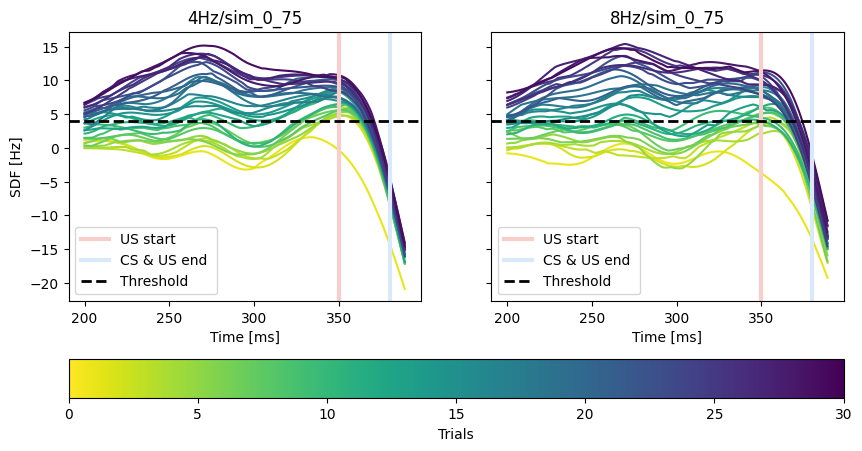

In [32]:
palette = list(reversed(sns.color_palette("viridis", n_trials).as_hex()))
sm = plt.cm.ScalarMappable(cmap="viridis_r", norm=plt.Normalize(vmin=0, vmax=n_trials))

fig_sdf, axs_sdf = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
for trial in range(n_trials):
    axs_sdf[0].plot(range(t_bs,390),cr_sdf[trial],palette[trial])
    axs_sdf[1].plot(range(t_bs,390),cr_sdf_1[trial], palette[trial])

#axs_sdf[0].axvline(CS_start_first, label="CS start", linewidth=3, c=CS_color)
axs_sdf[0].axvline(
    US_start_first - between_start, label="US start", linewidth=3, c=US_color
)
axs_sdf[0].axvline(
    CS_start_first + CS_burst_dur, label="CS & US end ", linewidth=3, c=CS_color
)
#axs_sdf[1].axvline(CS_start_first, label="CS start", linewidth=3, c=CS_color)
axs_sdf[1].axvline(
    US_start_first - between_start, label="US start", linewidth=3, c=US_color
)
axs_sdf[1].axvline(
    CS_start_first + CS_burst_dur, label="CS & US end ", linewidth=3, c=CS_color
)
axs_sdf[0].axhline(
    thr, linewidth=2, c='black', linestyle='--', label = "Threshold"
)
axs_sdf[1].axhline(
    thr, linewidth=2, c='black', linestyle='--', label = "Threshold"
)
axs_sdf[0].set_ylabel("SDF [Hz]")
axs_sdf[0].set_xlabel("Time [ms]")
axs_sdf[1].set_xlabel("Time [ms]")
axs_sdf[0].set_title(cond)
axs_sdf[1].set_title(cond_1)
axs_sdf[0].legend()
axs_sdf[1].legend()
cbar = plt.colorbar(sm, ax=axs_sdf.ravel().tolist(), orientation='horizontal')
cbar.set_label('Trials')


plt.show()

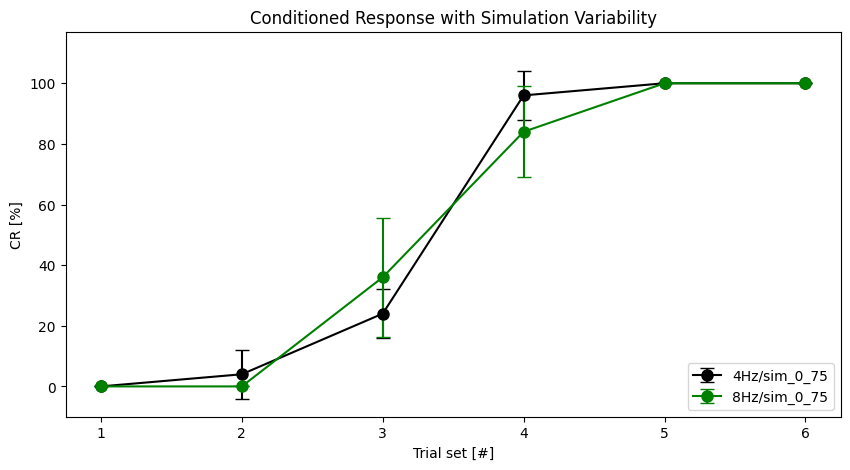

In [33]:
trial_chunk = 6
n_trials_chunck = 5
cr_perc_sim = []
cr_perc_sim_1 = []
bs_sim = []
bs_sim_1 = []
sdf_mean_sim_arr = np.array(sdf_mean_sim)
sdf_mean_sim_arr_1 = np.array(sdf_mean_sim_1)
from matplotlib.ticker import MultipleLocator

plt.figure(figsize=(10, 5))
for sim in range(5):
    bs_sim = np.median(sdf_mean_sim_arr[sim,1:4,t_bs])
    bs_sim_1 = np.median(sdf_mean_sim_arr_1[sim,1:4,t_bs])

    cr_baseline = sdf_mean_sim_arr[sim,:,t_bs:] - bs_sim
    cr_baseline_1 = sdf_mean_sim_arr_1[sim,:,t_bs:] - bs_sim_1

    cr_perc = []
    cr_perc_1 = []
    for i in range(trial_chunk):
        over_thr = []
        over_thr_1 = []
        for trial in range(0+n_trials_chunck*i, n_trials_chunck+n_trials_chunck*i):
            sdf_over = cr_baseline[trial,5:cr_window]>thr
            sdf_over_perc= len(np.where(sdf_over)[0])/(cr_window-5) # 144 (from 5 to 150)
            if any(sdf_over) and sdf_over_perc >= 0.75:
                over_thr.append(1)
            else:
                over_thr.append(0)
            sdf_over_1 = cr_baseline_1[trial,5:cr_window]>thr
            sdf_over_perc_1 = len(np.where(sdf_over_1)[0])/(cr_window-5) # 144 (from 5 to 150)
            if any(sdf_over_1) and sdf_over_perc_1 >= 0.75:
                over_thr_1.append(1)
            else:
                over_thr_1.append(0)

        cr_perc.append(sum(over_thr)/len(over_thr)*100)
        cr_perc_1.append(sum(over_thr_1)/len(over_thr_1)*100)
        

    cr_perc_sim.append(cr_perc)
    cr_perc_sim_1.append(cr_perc_1)

cr_perc_sim = np.stack(cr_perc_sim, axis=0)
cr_perc_sim_1 = np.stack(cr_perc_sim_1, axis=0)

median_cr = np.mean(cr_perc_sim, axis=0)
median_cr_1= np.mean(cr_perc_sim_1, axis=0)
std_cr_glut = np.std(cr_perc_sim, axis=0)
std_cr_gaba = np.std(cr_perc_sim_1, axis=0)

x = range(1,trial_chunk+1)

from matplotlib.ticker import MultipleLocator

plt.figure(figsize=(10, 5))
plt.errorbar(x, median_cr, yerr=std_cr_glut, fmt='-o', color='black', 
             label=cond, capsize=5, markersize=8)
plt.errorbar(x, median_cr_1, yerr=std_cr_gaba, fmt='-o', color='g', 
             label=cond_1, capsize=5, markersize=8)

# Setting labels and title
plt.xlabel('Trial set [#]')
plt.ylabel('CR [%]')
plt.title('Conditioned Response with Simulation Variability')

# Configure axis properties
plt.ylim(-10, 117)
#plt.xlim(0.5, n_trials + 0.5)
plt.gca().xaxis.set_major_locator(MultipleLocator(1))

# Add grid for better readability
#plt.grid(True, linestyle='--', alpha=0.7)

# Add legend
plt.legend(loc='lower right')


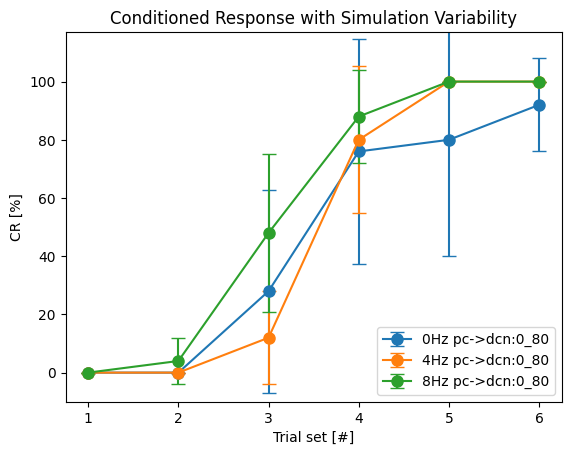

In [ ]:
root_path = f"/home/csartor1/code/NODS/results/dcn/wo_NO/"
cell = "dcn_spikes"
noise = [0,4,8]
pc_dcn = '0_65'
from matplotlib.ticker import MultipleLocator
t_bs = 200
cr_window = 300 - t_bs
thr = 4
step = 5
for noise_rate in noise:
    cond = f"{noise_rate}Hz/sim_{pc_dcn}"
    results_path = root_path + cond
    sdf_mean_sim = []
    for i in range(5):
        sim_path = f"{results_path}_{i}/"
        spk = get_spike_activity(cell_name=cell, path=sim_path)
        sdf_mean_cell = []
        for trial in range(n_trials):
            start = trial * between_start
            stop = CS_start_first + CS_burst_dur + trial * between_start
            sdf_cell_glut = sdf(start=start, stop=stop, spk=spk, step=step)
            sdf_mean_cell.append(sdf_mean(sdf_cell_glut))

        sdf_mean_sim.append(sdf_mean_cell)

    sdf_mean_stack = np.stack(sdf_mean_sim, axis=0)
    sdf_median = np.median(sdf_mean_stack, axis=0)
    
    trial_chunk = 6
    n_trials_chunck = 5
    cr_perc_sim = []
    cr_perc_sim_1 = []
    bs_sim = []
    sdf_mean_sim_arr = np.array(sdf_mean_sim)

    for sim in range(5):
        bs_sim = np.median(sdf_mean_sim_arr[sim,1:4,t_bs])

        cr_baseline = sdf_mean_sim_arr[sim,:,t_bs:] - bs_sim

        cr_perc = []
        for i in range(trial_chunk):
            over_thr = []
            for trial in range(0+n_trials_chunck*i, n_trials_chunck+n_trials_chunck*i):
                sdf_over = cr_baseline[trial,5:cr_window]>thr
                sdf_over_perc= len(np.where(sdf_over)[0])/(cr_window-5) # 144 (from 5 to 150)
                if any(sdf_over) and sdf_over_perc >= 0.75:
                    over_thr.append(1)
                else:
                    over_thr.append(0)

            cr_perc.append(sum(over_thr)/len(over_thr)*100)            

        cr_perc_sim.append(cr_perc)

    cr_perc_sim = np.stack(cr_perc_sim, axis=0)

    median_cr = np.mean(cr_perc_sim, axis=0)
    std_cr = np.std(cr_perc_sim, axis=0)

    x = range(1,trial_chunk+1)

    plt.errorbar(x, median_cr, yerr=std_cr, fmt='-o', 
                label=f"{noise_rate}Hz pc->dcn:{pc_dcn}", capsize=5, markersize=8)

# Setting labels and title
plt.xlabel('Trial set [#]')
plt.ylabel('CR [%]')
plt.title('Conditioned Response with Simulation Variability')

# Configure axis properties
plt.ylim(-10, 117)
#plt.xlim(0.5, n_trials + 0.5)
plt.gca().xaxis.set_major_locator(MultipleLocator(1))

# Add grid for better readability
#plt.grid(True, linestyle='--', alpha=0.7)

# Add legend
plt.legend(loc='lower right')

plt.show() 
  

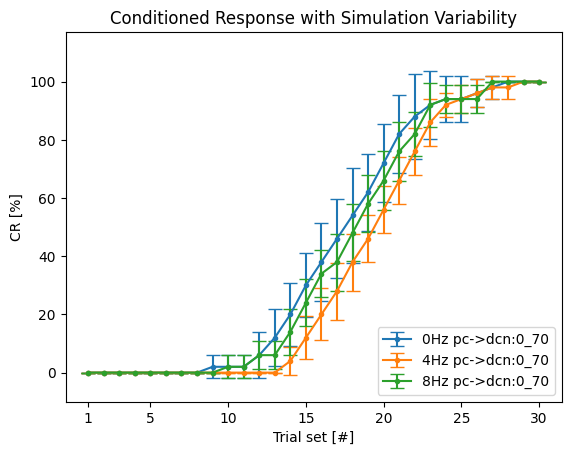

In [ ]:
root_path = f"/home/csartor1/code/NODS/results/dcn/wo_NO/"
cell = "dcn_spikes"
noise = [0,4,8]
pc_dcn = '0_70'
from matplotlib.ticker import MultipleLocator
t_bs = 200
cr_window = 300 - t_bs
thr = 4
step = 5
for noise_rate in noise:
    cond = f"{noise_rate}Hz/sim_{pc_dcn}"
    results_path = root_path + cond
    sdf_mean_sim = []
    for i in range(5):
        sim_path = f"{results_path}_{i}/"
        spk = get_spike_activity(cell_name=cell, path=sim_path)
        sdf_mean_cell = []
        for trial in range(n_trials):
            start = trial * between_start
            stop = CS_start_first + CS_burst_dur + trial * between_start
            sdf_cell_glut = sdf(start=start, stop=stop, spk=spk, step=step)
            sdf_mean_cell.append(sdf_mean(sdf_cell_glut))

        sdf_mean_sim.append(sdf_mean_cell)

    sdf_mean_stack = np.stack(sdf_mean_sim, axis=0)
    sdf_median = np.median(sdf_mean_stack, axis=0)
    
    trial_chunk = 6
    n_trials_chunck = 5
    cr_perc_sim = []
    bs_sim = []
    sdf_mean_sim_arr = np.array(sdf_mean_sim)

    for sim in range(5):
        bs_sim = np.median(sdf_mean_sim_arr[sim,1:4,t_bs])

        cr_baseline = sdf_mean_sim_arr[sim,:,t_bs:] - bs_sim

        over_thr = []
        for trial in range(n_trials):
            sdf_over = cr_baseline[trial,5:cr_window]>thr
            sdf_over_perc= len(np.where(sdf_over)[0])/(cr_window-5) # 144 (from 5 to 150)
            if any(sdf_over) and sdf_over_perc >= 0.75:
                over_thr.append(1)
            else:
                over_thr.append(0)

        cr_perc_avg = moving_average_left(over_thr, 10)*100

        cr_perc_sim.append(cr_perc_avg)

    cr_perc_sim = np.stack(cr_perc_sim, axis=0)

    median_cr = np.mean(cr_perc_sim, axis=0)
    std_cr = np.std(cr_perc_sim, axis=0)

    x = range(1,n_trials+1)

    plt.errorbar(x, median_cr, yerr=std_cr, fmt='-o', 
                label=f"{noise_rate}Hz pc->dcn:{pc_dcn}", capsize=5, markersize=3)

# Setting labels and title
plt.xlabel('Trial set [#]')
plt.ylabel('CR [%]')
plt.xticks([1, 5, 10, 15, 20, 25, 30])
plt.title('Conditioned Response with Simulation Variability')
# Configure axis properties
plt.ylim(-10, 117)
#plt.xlim(0.5, n_trials + 0.5)

# Add grid for better readability
#plt.grid(True, linestyle='--', alpha=0.7)

# Add legend
plt.legend(loc='lower right')

plt.show()